# Backbone network · Persistent path perplexity

# 1. Backbone network

## 0) 설정

In [7]:
from pathlib import Path
from collections import defaultdict
import os, pickle, time

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree

# ── 경로 ─────────────────────────────────────────────────────────────
# 저장소 루트. 다른 위치에서 실행하려면 환경변수 SCISOC_BASE로 덮어쓴다.
BASE = Path(os.environ.get("SCISOC_BASE", ".."))
NET  = BASE / "data" / "processed" / "networks_emb"         # 입력 npz
PROC = BASE / "data" / "processed"   # backbone/ 이 떨어지는 곳
TAB  = BASE / "results" / "tables"    # 결과표
TAB.mkdir(parents=True, exist_ok=True)
for sub in ("backbone",):
    (PROC / sub).mkdir(parents=True, exist_ok=True)

# ── 공통 상수 ────────────────────────────────────────────────────────
YEARS   = list(range(1990, 2024))
SOURCES = ["news", "paper"]
NY      = len(YEARS)
NC      = 29312                      # 필터 어휘 크기

# 1단계 — 백본
DEG_TARGET    = 3        # |E_t| = DEG_TARGET * N_t  → 평균 연결선수 6
ALPHA_REF     = 0.05     # 고정 alpha를 썼다면 어땠을지, 진단용으로만 기록
RETENTION_REF = 0.10     # 잔류율 고정 민감도


## 1) 백본 추출 — disparity filter

`alpha_ij = 1 - (k_i-1)∫₀^{p_ij}(1-x)^{k_i-2}dx = (1-p_ij)^{k_i-1}`

닫힌형을 쓰는 이유는 속도뿐입니다 (`scipy.integrate.quad`로 적분한 값과
오차 1e-15). `k_i = 1`이면 정의되지 않으므로 alpha = 1로 두어 그 끝점에서는
유의해질 수 없게 하고, 반대쪽 끝점 또는 MST 합집합으로만 들어오게 합니다.

In [8]:
(PROC / "backbone").mkdir(parents=True, exist_ok=True)

def edge_alphas(A):
    """Upper-triangle edge list of a symmetric CSR matrix with disparity alphas."""
    U = sp.triu(A, k=1).tocoo()
    i, j, w = U.row.astype(np.int32), U.col.astype(np.int32), U.data.astype(np.float64)

    deg = np.asarray((A != 0).sum(axis=1)).ravel().astype(np.float64)
    stg = np.asarray(A.sum(axis=1)).ravel().astype(np.float64)

    def side(node, w):
        k = deg[node]
        s = stg[node]
        p = np.divide(w, s, out=np.zeros_like(w), where=s > 0)
        a = np.power(np.clip(1.0 - p, 0.0, 1.0), k - 1.0)
        return np.where(k > 1, a, 1.0)          # k = 1 -> undefined, never significant

    a_i, a_j = side(i, w), side(j, w)
    return i, j, w, a_i, a_j, np.minimum(a_i, a_j), deg, stg


def max_spanning_tree_edges(A, n):
    """Edge set (as i*n+j keys, i<j) of the maximum spanning tree of A."""
    U = sp.triu(A, k=1).tocoo()
    wmax = U.data.max()
    T = sp.coo_matrix((wmax + 1.0 - U.data, (U.row, U.col)), shape=A.shape).tocsr()
    M = minimum_spanning_tree(T).tocoo()        # monotone-decreasing transform
    lo = np.minimum(M.row, M.col).astype(np.int64)
    hi = np.maximum(M.row, M.col).astype(np.int64)
    return lo * n + hi


def run_one(source, year):
    A = sp.load_npz(NET / f"{source}_{year}_adj_f.npz").tocsr()
    A.eliminate_zeros()
    n = A.shape[0]

    i, j, w, a_i, a_j, a_min, deg, stg = edge_alphas(A)
    m = len(w)
    n_active = int((deg > 0).sum())
    target = min(DEG_TARGET * n_active, m)

    # rank by alpha_min ascending, ties broken by descending weight
    order = np.lexsort((-w, a_min))
    keep = order[:target]
    implied_alpha = float(a_min[keep[-1]])
    cut_rank_alpha = float(a_min[order[target - 1]]) if target < m else 1.0

    # maximum spanning tree union
    mst_keys = max_spanning_tree_edges(A, n)
    key_all = i.astype(np.int64) * n + j.astype(np.int64)
    in_mst = np.isin(key_all, mst_keys)
    kept_mask = np.zeros(m, dtype=bool)
    kept_mask[keep] = True
    mst_only = in_mst & ~kept_mask
    sel = np.where(kept_mask | mst_only)[0]

    # write edge table
    df = pd.DataFrame({
        "i": i[sel], "j": j[sel],
        "w": np.round(w[sel], 6),
        "alpha_i": a_i[sel], "alpha_j": a_j[sel], "alpha_min": a_min[sel],
        "mst_only": mst_only[sel].astype(np.int8),
    })
    path = PROC / "backbone" / f"{source}_{year}_backbone.csv.gz"
    df.to_csv(path, index=False, float_format="%.6g", compression="gzip")

    # ---- diagnostics on the 3N backbone (without the MST additions) -----
    bi, bj = i[keep], j[keep]
    nodes_bb = np.unique(np.concatenate([bi, bj]))
    B = sp.coo_matrix((np.ones(len(bi)), (bi, bj)), shape=(n, n))
    B = (B + B.T).tocsr()
    ncomp, lab = connected_components(B[nodes_bb][:, nodes_bb], directed=False)
    lcc = np.bincount(lab).max() / len(nodes_bb)

    # with the MST union added
    si, sj = i[sel], j[sel]
    nodes_u = np.unique(np.concatenate([si, sj]))
    U = sp.coo_matrix((np.ones(len(si)), (si, sj)), shape=(n, n))
    U = (U + U.T).tocsr()
    ncomp_u, lab_u = connected_components(U[nodes_u][:, nodes_u], directed=False)
    lcc_u = np.bincount(lab_u).max() / len(nodes_u)

    # ---- diagnostics: what a FIXED alpha would have done ----------------
    n_a05 = int((a_min < ALPHA_REF).sum())

    # ---- sensitivity: fixed 10% retention -------------------------------
    # The two cuts are prefixes of the SAME alpha ordering, so they are nested
    # and their overlap is fixed by the size ratio; what the sensitivity tests
    # is how deep the cut goes, not which edges are eligible.
    t10 = max(int(round(RETENTION_REF * m)), 1)
    inter = min(len(keep), t10)
    jac = inter / (len(keep) + t10 - inter)

    # ---- does the disparity filter differ from plain weight thresholding? -
    top_w = np.argsort(-w, kind="stable")[:target]
    ov = len(np.intersect1d(keep, top_w, assume_unique=False))
    jac_w = ov / (2 * target - ov)

    return df, {
        "source": source, "year": year,
        "n_nodes_active": n_active, "n_edges_total": m,
        "total_weight": float(w.sum()),
        # primary backbone
        "target_edges_3N": int(target),
        "implied_alpha": implied_alpha,
        "retention_rate": target / m,
        "backbone_nodes": int(len(nodes_bb)),
        "node_coverage": len(nodes_bb) / n_active,
        "mean_degree_backbone": 2 * target / len(nodes_bb),
        "weight_share_retained": float(w[keep].sum() / w.sum()),
        "n_components": int(ncomp), "lcc_share": float(lcc),
        # MST union
        "mst_added_edges": int(mst_only.sum()),
        "mst_added_share": float(mst_only.sum() / target),
        "n_components_with_mst": int(ncomp_u), "lcc_share_with_mst": float(lcc_u),
        "union_nodes": int(len(nodes_u)),
        "union_node_coverage": len(nodes_u) / n_active,
        "union_edges": int(len(sel)),
        "mean_degree_union": 2 * len(sel) / len(nodes_u),
        "weight_share_union": float(w[sel].sum() / w.sum()),
        # diagnostics
        "n_edges_alpha_lt_0.05": n_a05,
        "retention_alpha_0.05": n_a05 / m,
        "mean_degree_alpha_0.05": 2 * n_a05 / n_active,
        "sens10_target_edges": t10,
        "sens10_implied_alpha": float(a_min[order[t10 - 1]]),
        "sens10_jaccard_vs_3N": jac,
        "sens10_mean_degree": 2 * t10 / n_active,
        "jaccard_alpha_vs_topweight": jac_w,
    }


def run_stage1_backbone():
    rows = []
    for source in SOURCES:
        for year in YEARS:
            t0 = time.time()
            _, stat = run_one(source, year)
            rows.append(stat)
            print(f"{source} {year}  N={stat['n_nodes_active']:>6}  "
                  f"E={stat['n_edges_total']:>9}  keep={stat['target_edges_3N']:>6}  "
                  f"alpha_t={stat['implied_alpha']:.4g}  "
                  f"cov={stat['node_coverage']:.3f}  "
                  f"mst+={stat['mst_added_edges']:>5}  "
                  f"({time.time()-t0:.1f}s)", flush=True)
    pd.DataFrame(rows).to_csv(TAB / "backbone_summary.csv", index=False)

    subs = pickle.load(open(NET / "global_subjects_filtered.pkl", "rb"))
    pd.DataFrame({"index": np.arange(len(subs)), "subject": subs}).to_csv(
        TAB / "backbone_vocab.csv", index=False)
    print("\ndone ->", PROC)

### 1.1 실행

In [9]:
run_stage1_backbone()

news 1990  N=  2260  E=    40084  keep=  6780  alpha_t=0.203  cov=0.581  mst+= 1041  (0.1s)
news 1991  N=  1538  E=    14386  keep=  4614  alpha_t=0.3682  cov=0.723  mst+=  647  (0.1s)
news 1992  N=  2306  E=    38797  keep=  6918  alpha_t=0.2118  cov=0.576  mst+= 1088  (0.1s)
news 1993  N=  2352  E=    37597  keep=  7056  alpha_t=0.2271  cov=0.614  mst+= 1068  (0.1s)
news 1994  N=  2535  E=    46120  keep=  7605  alpha_t=0.1924  cov=0.591  mst+= 1150  (0.1s)
news 1995  N=  2496  E=    40410  keep=  7488  alpha_t=0.2221  cov=0.604  mst+= 1127  (0.1s)
news 1996  N=  2514  E=    34072  keep=  7542  alpha_t=0.2711  cov=0.640  mst+= 1142  (0.1s)
news 1997  N=  2606  E=    38438  keep=  7818  alpha_t=0.2429  cov=0.646  mst+= 1174  (0.1s)
news 1998  N=  4348  E=   125991  keep= 13044  alpha_t=0.09564  cov=0.535  mst+= 2116  (0.2s)
news 1999  N=  4598  E=   138476  keep= 13794  alpha_t=0.08922  cov=0.528  mst+= 2253  (0.3s)
news 2000  N=  4667  E=   148091  keep= 14001  alpha_t=0.08007  cov=0

### 1.2 검증

산출물이 스스로 주장하는 성질을 다시 확인합니다 — 엣지표 형식, 밀도 성장
아티팩트 제거 여부, 노드 커버리지, 연결성, 잔류 가중치, 그리고 단순
가중치 상위컷과 정말 다른지.

In [10]:
FAIL = []

def check(name, ok, detail=""):
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}" + (f"  {detail}" if detail else ""))
    if not ok:
        FAIL.append(name)

print("edge tables are well formed")
S_ = pd.read_csv(TAB / "backbone_summary.csv")
bad = []
for src in ["news", "paper"]:
    for yr in [1990, 2005, 2023]:
        d = pd.read_csv(PROC / "backbone" / f"{src}_{yr}_backbone.csv.gz")
        row = S_[(S_.source == src) & (S_.year == yr)].iloc[0]
        if len(d) != row.union_edges:
            bad.append((src, yr, "row count"))
        if (d.i >= d.j).any():
            bad.append((src, yr, "i<j violated"))
        if d.duplicated(["i", "j"]).any():
            bad.append((src, yr, "duplicate edge"))
        if (d.w <= 0).any():
            bad.append((src, yr, "non-positive weight"))
        if not np.allclose(d.alpha_min, np.minimum(d.alpha_i, d.alpha_j), atol=1e-6):
            bad.append((src, yr, "alpha_min != min"))
        # every non-MST edge must be at or below the implied alpha cut-off
        core = d[d.mst_only == 0]
        if core.alpha_min.max() > row.implied_alpha * (1 + 1e-5) + 1e-12:
            bad.append((src, yr, "alpha above cut-off"))
check("6 spot-checked year files consistent", not bad, str(bad))

print("\n3. the density rule removes the growth artefact")
for src in ["news", "paper"]:
    d = S_[S_.source == src]
    r_fixed = np.corrcoef(d.year, d["mean_degree_alpha_0.05"])[0, 1]
    r_ours = np.corrcoef(d.year, d["mean_degree_union"])[0, 1]
    g_fixed = d["mean_degree_alpha_0.05"].iloc[-1] / d["mean_degree_alpha_0.05"].iloc[0]
    g_ours = d["mean_degree_union"].iloc[-1] / d["mean_degree_union"].iloc[0]
    print(f"  {src:<6} mean degree vs year:  fixed alpha=0.05  r={r_fixed:+.3f} "
          f"({g_fixed:.2f}x)   |E|=3N + MST  r={r_ours:+.3f} ({g_ours:.2f}x)")
    check(f"{src}: backbone mean degree flat across the period",
          abs(g_ours - 1) < 0.10 and g_fixed > 2.0,
          f"ours {g_ours:.2f}x vs fixed-alpha {g_fixed:.2f}x")

print("\n4. node coverage and connectivity")
for src in ["news", "paper"]:
    d = S_[S_.source == src]
    check(f"{src}: every active concept is in the backbone",
          bool((d.union_node_coverage > 0.9999).all()),
          f"min={d.union_node_coverage.min():.4f}")
    check(f"{src}: largest component covers >95% of the backbone",
          bool((d.lcc_share_with_mst > 0.95).all()),
          f"min={d.lcc_share_with_mst.min():.4f}")

print("\n5. weight retained is stable across the period")
for src in ["news", "paper"]:
    d = S_[S_.source == src]
    dens = d.n_edges_total / d.n_nodes_active
    r = np.corrcoef(dens, d.weight_share_union)[0, 1]
    print(f"  {src:<6} weight share retained {d.weight_share_union.min():.3f}"
          f"-{d.weight_share_union.max():.3f} (sd {d.weight_share_union.std():.3f}), "
          f"corr with that year's E/N = {r:+.2f}")

print("\n6. the filter is not equivalent to weight thresholding")
for src in ["news", "paper"]:
    d = S_[S_.source == src]
    print(f"  {src:<6} Jaccard(alpha-cut, top-weight cut) = "
          f"{d.jaccard_alpha_vs_topweight.min():.3f}-{d.jaccard_alpha_vs_topweight.max():.3f}")

print("\n" + ("ALL CHECKS PASSED" if not FAIL else f"FAILURES: {FAIL}"))

edge tables are well formed
  [PASS] 6 spot-checked year files consistent  []

3. the density rule removes the growth artefact
  news   mean degree vs year:  fixed alpha=0.05  r=+0.884 (4.33x)   |E|=3N + MST  r=+0.665 (1.01x)
  [PASS] news: backbone mean degree flat across the period  ours 1.01x vs fixed-alpha 4.33x
  paper  mean degree vs year:  fixed alpha=0.05  r=+0.987 (4.55x)   |E|=3N + MST  r=+0.945 (1.03x)
  [PASS] paper: backbone mean degree flat across the period  ours 1.03x vs fixed-alpha 4.55x

4. node coverage and connectivity
  [PASS] news: every active concept is in the backbone  min=1.0000
  [PASS] news: largest component covers >95% of the backbone  min=0.9883
  [PASS] paper: every active concept is in the backbone  min=1.0000
  [PASS] paper: largest component covers >95% of the backbone  min=0.9998

5. weight retained is stable across the period
  news   weight share retained 0.494-0.711 (sd 0.041), corr with that year's E/N = -0.62
  paper  weight share retained 0.527

### 1.3 참조 구현과 대조 (선택)

`aekpalakorn/python-backbone-network`를 받아 그 코드로 같은 연도의 백본을
뽑고 같은 엣지 수에서 비교합니다. alpha 값 자체는 동일하고, 차이는 그
저장소의 무방향 분기가 같은 엣지에 alpha를 덮어써서 OR 규칙이 아니라
*나중에 처리된 끝점*의 값을 남기는 데서만 옵니다.

In [11]:
# !git clone --depth 1 https://github.com/aekpalakorn/python-backbone-network /tmp/pbn
# (py2 print 문이 있는 __main__ 블록을 떼고 임포트)
import networkx as nx
from scipy import integrate

def _load_reference():
    src = Path("/tmp/pbn/backbone.py").read_text().split("if __name__ == '__main__':")[0]
    ns = {}
    exec(compile(src, "ref_backbone", "exec"), ns)
    return ns["disparity_filter"]

def compare_with_reference(source, year):
    ref_disparity_filter = _load_reference()
    A = sp.load_npz(NET / f"{source}_{year}_adj_f.npz").tocsr(); A.eliminate_zeros()
    i, j, w, a_i, a_j, a_min, deg, _ = edge_alphas(A)
    n_active = int((deg > 0).sum())
    target = min(DEG_TARGET * n_active, len(w))
    ours = set(map(tuple, np.c_[i, j][np.lexsort((-w, a_min))[:target]]))

    G = nx.Graph()
    U = sp.triu(A, k=1).tocoo()
    G.add_weighted_edges_from(zip(U.row.tolist(), U.col.tolist(), U.data.tolist()))
    B = ref_disparity_filter(G)
    el = sorted(B.edges(data=True), key=lambda e: (e[2]["alpha"], -e[2]["weight"]))
    repo = set((min(u, v), max(u, v)) for u, v, _ in el[:target])
    inter = len(ours & repo)
    print(f"{source} {year}: backbone {target} edges, 공통 {inter} = {inter/target:.1%}, "
          f"Jaccard {inter/(2*target-inter):.4f}")

def check_closed_form_vs_quad(source="news", year=1990, n_hub=400):
    """닫힌형 alpha가 Eq.(2)의 수치적분과 같은지 실데이터로 전수 확인."""
    A = sp.load_npz(NET / f"{source}_{year}_adj_f.npz").tocsr()
    deg = np.asarray((A != 0).sum(1)).ravel()
    S = A[np.argsort(-deg)[:n_hub]][:, np.argsort(-deg)[:n_hub]].tocsr()
    S.eliminate_zeros()
    i, j, w, a_i, a_j, _, _, _ = edge_alphas(S)
    k = np.asarray((S != 0).sum(1)).ravel(); s = np.asarray(S.sum(1)).ravel()
    d = []
    for node, ww, a in ((i, w, a_i), (j, w, a_j)):
        for nd, x, av in zip(node, ww, a):
            if k[nd] <= 1:
                continue
            q = 1 - (k[nd]-1) * integrate.quad(lambda t: (1-t)**(k[nd]-2), 0, x/s[nd])[0]
            d.append(abs(av - q))
    print(f"닫힌형 vs quad: 최대 오차 {max(d):.3e}  (끝점 {len(d):,}개)")

# check_closed_form_vs_quad()
# for y in (1990, 2005, 2023): compare_with_reference("news", y)


## 2) 엣지 지속성

엣지가 그 해 **백본 본체**(`mst_only == 0`; MST 추가분은 연결성 보수이지
유의한 엣지가 아니므로 제외)에 있으면 그 해에 존재한 것으로 봅니다.
엣지마다 총 등장연수와 **최장 연속 구간**을 기록합니다.

In [12]:
def presence_matrix(source, include_mst=False):
    """dict edge_key -> bool vector over the 34 years, plus the weight matrix."""
    pres = {}
    wts = {}
    for yi, y in enumerate(YEARS):
        d = pd.read_csv(PROC / "backbone" / f"{source}_{y}_backbone.csv.gz")
        if not include_mst:
            d = d[d.mst_only == 0]
        keys = d.i.values.astype(np.int64) * 29312 + d.j.values.astype(np.int64)
        for k, w in zip(keys, d.w.values):
            v = pres.get(k)
            if v is None:
                v = np.zeros(NY, dtype=bool)
                pres[k] = v
                wts[k] = np.zeros(NY, dtype=np.float32)
            v[yi] = True
            wts[k][yi] = w
    return pres, wts


def runs(v):
    """(longest consecutive run, start index of that run)."""
    best = cur = 0
    best_s = s = 0
    for t, x in enumerate(v):
        if x:
            if cur == 0:
                s = t
            cur += 1
            if cur > best:
                best, best_s = cur, s
        else:
            cur = 0
    return best, best_s


def edge_table(source, include_mst=False):
    pres, wts = presence_matrix(source, include_mst)
    rows = []
    for k, v in pres.items():
        r, s = runs(v)
        rows.append((k // 29312, k % 29312, int(v.sum()), r,
                     YEARS[s], YEARS[s + r - 1],
                     float(wts[k][v].mean()), float(wts[k][v].min())))
    df = pd.DataFrame(rows, columns=["i", "j", "years_present", "longest_run",
                                     "run_start", "run_end", "w_mean", "w_min"])
    return df.sort_values(["longest_run", "years_present", "w_mean"],
                          ascending=False).reset_index(drop=True)



def run_stage2_persistence():
    summary = []
    for source in ["news", "paper"]:
        df = edge_table(source)
        df.to_csv(TAB / f"{source}_edge_persistence.csv.gz",
                  index=False, float_format="%.6g", compression="gzip")
        print(f"\n{source}: {len(df):,} distinct backbone edges over 34 years")
        prof = df.longest_run.value_counts().sort_index(ascending=False)
        print("  longest consecutive run -> n edges (top):")
        for r in [34, 30, 25, 20, 15, 10, 5, 1]:
            n = int((df.longest_run >= r).sum())
            print(f"    >= {r:>2} years : {n:>8,}")
            summary.append({"source": source, "min_run": r, "n_edges": n})
    pd.DataFrame(summary).to_csv(TAB / "persistence_profile.csv", index=False)

In [13]:
run_stage2_persistence()


news: 160,112 distinct backbone edges over 34 years
  longest consecutive run -> n edges (top):
    >= 34 years :      163
    >= 30 years :      393
    >= 25 years :    1,495
    >= 20 years :    2,155
    >= 15 years :    3,302
    >= 10 years :    6,361
    >=  5 years :   16,367
    >=  1 years :  160,112

paper: 196,246 distinct backbone edges over 34 years
  longest consecutive run -> n edges (top):
    >= 34 years :    9,674
    >= 30 years :   12,422
    >= 25 years :   16,799
    >= 20 years :   22,997
    >= 15 years :   29,570
    >= 10 years :   38,297
    >=  5 years :   56,797
    >=  1 years :  196,246


# 2. Persistent path sequence & sequence perplexity

위에서 만든 **엣지별 지속 구간**(`results/tables/{news,paper}_edge_persistence.csv.gz`)을
받아, 여기서부터는 **persistent path**를 뽑아 임베딩으로 연도별 perplexity를 잰다.

**persistent path**란 `v₁ – v₂ – … – v_K` 사슬 중에서 **K−1개 엣지가 전부 동시에** 백본에
남아 있는 연속 구간이 `L`년 이상인 것을 말한다. 엣지 하나하나가 오래간 것이 아니라
사슬 전체가 같은 기간 동안 함께 유지되어야 한다.

## 1) Persistent path perplexity with dynamic graph embedding

백본에서 **L년 이상 연속 지속된 개념 시퀀스**를 뽑아, 기존 LexicalDySAT 임베딩으로
**연도별 perplexity**를 계산한다.

### 설계

| 항목 | 값 |
|---|---|
| 지속 기준 | 시퀀스의 모든 엣지가 **동시에** 백본에 있는 연속 구간 ≥ `L`년 |
| 시퀀스 길이 | `K` 노드 (스텝 `K−1`개) |
| 조건부 | **앞의 것만** (autoregressive) → 연쇄법칙 성립 → pseudo 아닌 **진짜 perplexity** |
| 문맥 벡터 | 앞선 노드 좌표의 감쇠 가중평균 (`LAM`) — 최근일수록 큰 가중치 |
| 확률 | `softmax( c · z_u )`, 후보 = 그 해 활성 개념 전부, 이미 지나온 노드는 제외 |
| 방향 | 무방향 네트워크이므로 정·역 양방향 평균 |
| 임베딩 | 기존 `embeddings/{src}_embeddings.pt` `[34, 29312, 32]` — **재학습 없음** |

### 지표 두 개

- **PP** = `exp(−평균 log p)` — "스텝당 몇 지선다만큼 헷갈렸나"
- **순위** = 진짜 다음 개념이 후보 중 몇 등인가 — 임베딩 눈금 보정에 영향받지 않음

## 0) 설정

In [14]:
import gzip, csv, os, zipfile, collections
import numpy as np

# 이 절이 읽는 입력 (BASE·YEARS·SOURCES·NC 는 노트북 첫 셀에서 정의):
#   (아래 파일은 저장소에 포함되지 않는다 — README 참조)
#     {BASE}/data/processed/embeddings/{news,paper}_embeddings.pt            [34, 29312, 32], 각 127MB
#     {BASE}/data/processed/networks_emb/{news,paper}_{1990..2023}_adj_f.npz  연도별 공출현 행렬
#     {BASE}/results/tables/backbone_vocab.csv                                개념 인덱스 -> 이름
#     {BASE}/results/tables/{news,paper}_edge_persistence.csv.gz              백본 엣지 지속 구간
SEQ   = os.path.join(BASE, "results", "sequences")   # 표·중간산출물
FIG   = os.path.join(BASE, "results", "figures")     # 그림
os.makedirs(FIG, exist_ok=True)
os.makedirs(SEQ, exist_ok=True)

L      = 20        # 지속 기준 (년)
KS     = [6, 8]    # 시퀀스 길이
NSEQ   = 2000      # 코퍼스·K당 시퀀스 수
LAM    = 0.5       # 문맥 감쇠 (1.0 = 단순평균, 작을수록 최근 강조)
N_NODE = NC                         # 필터 어휘 크기 (위에서 정의)

print(BASE, "\nL =", L, " K =", KS, " NSEQ =", NSEQ, " LAM =", LAM)

.. 
L = 20  K = [6, 8]  NSEQ = 2000  LAM = 0.5


## 1) 임베딩 읽기

`.pt`는 torch 없이도 읽을 수 있다 — zip 안에 float32 원시 바이트가 통째로 들어 있다.

In [15]:
def load_emb(src, shape=(34, N_NODE, 32)):
    """전체 임베딩이 있으면 그것을, 없으면 저장소에 포함된 샘플을 읽는다.

    전체 (embeddings/{src}_embeddings.pt, 122MB) — 34개 연도. torch 없이
    zip으로 열어 float32 원시 바이트를 직접 읽는다.
    샘플 (embeddings/{src}_embeddings_sample.npy, 11MB) — 1995·2010·2023년만.
    """
    full = f"{BASE}/data/processed/embeddings/{src}_embeddings.pt"
    if os.path.exists(full):
        z = zipfile.ZipFile(full)
        name = [i.filename for i in z.infolist() if i.filename.endswith("data/0")][0]
        return np.frombuffer(z.read(name), dtype="<f4").reshape(shape)

    samp = f"{BASE}/data/processed/embeddings/{src}_embeddings_sample.npy"
    if os.path.exists(samp):
        E = np.load(samp)
        print(f"⚠ 전체 임베딩이 없어 샘플을 사용합니다 ({src}): {E.shape}"
              " — 1995·2010·2023년만. 아래 분석은 전체 34년을 전제하므로 결과가 다릅니다.")
        return E

    raise FileNotFoundError(
        f"임베딩이 없습니다.\n  전체: {full}\n  샘플: {samp}\n"
        "README의 '데이터' 절을 참고해 embeddings/ 에 파일을 넣으세요.")

# 확인 — 저장소에 news 샘플이 있으므로 news 로 점검한다
_e = load_emb("news")
print(_e.shape, _e.dtype, "노드 norm 평균 =",
      round(float(np.linalg.norm(_e[-1], axis=1).mean()), 3))
del _e

(34, 29312, 32) float32 노드 norm 평균 = 0.589


## 2) 지속 백본 네트워크

`{src}_edge_persistence.csv.gz`의 `longest_run ≥ L`인 엣지만 남긴다.
각 엣지의 최장 연속 구간 `[run_start, run_end]`도 함께 들고 있다가,
시퀀스의 지속 구간 = **모든 엣지 구간의 교집합**으로 계산한다.

In [16]:
def persistent_graph(src, L=L):
    E, adj = {}, collections.defaultdict(list)
    with gzip.open(f"{BASE}/results/tables/{src}_edge_persistence.csv.gz", "rt") as fh:
        for r in csv.DictReader(fh):
            if int(r["longest_run"]) >= L:
                i, j = int(r["i"]), int(r["j"])
                E[(min(i,j), max(i,j))] = (int(r["run_start"]), int(r["run_end"]))
                adj[i].append(j); adj[j].append(i)
    return E, {k: np.array(v) for k, v in adj.items()}

for src in SOURCES:
    E, adj = persistent_graph(src)
    deg = np.array([len(v) for v in adj.values()])
    print(f"{src:6} L>={L}: 엣지 {len(E):>7,}  개념 {len(adj):>6,}  "
          f"연결선수 중앙값 {int(np.median(deg))} 평균 {deg.mean():.1f} 최대 {deg.max()}")

news   L>=20: 엣지   2,155  개념    863  연결선수 중앙값 1 평균 5.0 최대 774
paper  L>=20: 엣지  22,997  개념  4,379  연결선수 중앙값 3 평균 10.5 최대 1621


### 허브 점검

랜덤워크 표본은 연결선수가 큰 노드로 편향된다. 어떤 개념이 허브인지 먼저 본다.

In [17]:
vocab = {}
with open(f"{BASE}/results/tables/backbone_vocab.csv") as f:
    rd = csv.DictReader(f); ks = rd.fieldnames
    for r in rd: vocab[int(r[ks[0]])] = r[ks[1]]

for src in SOURCES:
    E, adj = persistent_graph(src)
    top = sorted(((len(v), k) for k, v in adj.items()), reverse=True)[:6]
    print(f"--- {src}"); [print(f"   {d:5d}  {vocab.get(n, n)}") for d, n in top]

--- news
     774  automation
     244  software
      88  customer services
      82  alliances
      79  information systems
      51  marketing
--- paper
    1621  control (management)
    1501  image (mathematics)
     833  perspective (graphical)
     744  pattern recognition (psychology)
     741  process (computing)
     681  class (philosophy)


## 3) 시퀀스 표본 추출

백본 위 랜덤워크 → 단순경로(재방문 금지) → 구간 교집합이 `L`년 이상인 것만 채택.

> ⚠️ 랜덤워크는 **균일 표본이 아니다**. 허브 쪽으로 편향된다.

In [18]:
def sample_sequences(src, K, n=NSEQ, L=L, seed=0):
    E, adj = persistent_graph(src, L)
    rng = np.random.default_rng(seed)
    nodes = np.array(list(adj))
    deg   = np.array([len(adj[x]) for x in nodes])
    p     = deg / deg.sum()
    out, tries = {}, 0
    while len(out) < n and tries < n * 4000:
        tries += 1
        s = int(rng.choice(nodes, p=p)); path = [s]; seen = {s}; lo, hi = 1990, 2023
        for _ in range(K - 1):
            nb  = adj[path[-1]]
            nxt = int(nb[rng.integers(len(nb))])
            if nxt in seen: break
            a, b = E[(min(path[-1], nxt), max(path[-1], nxt))]
            lo, hi = max(lo, a), min(hi, b)
            if hi - lo + 1 < L: break
            path.append(nxt); seen.add(nxt)
        if len(path) == K:
            key = tuple(path) if path[0] < path[-1] else tuple(reversed(path))
            out.setdefault(key, (lo, hi))
    P   = np.array([list(k) for k in out])
    win = np.array([v for v in out.values()])
    return P, win, tries

# 예시 확인
P, win, tries = sample_sequences("paper", 6, n=200)
print(f"200개 뽑는 데 워크 {tries}회 (성립률 {200/tries:.1%})")
for row, w in list(zip(P, win))[:3]:
    print(f"  [{w[0]}-{w[1]}]  " + " → ".join(vocab.get(int(x), str(x)) for x in row))

200개 뽑는 데 워크 444회 (성립률 45.0%)
  [1990-2023]  intervention (counseling) → conceptualization → operationalization → variety (cybernetics) → state (computer science) → process (computing)
  [2003-2023]  nonparametric statistics → kernel (algebra) → bayesian probability → identification (biology) → word (group theory) → recall
  [2003-2023]  radiation therapy → computed tomography → contrast (vision) → politics → word (group theory) → sentence


## 4) 한 해의 perplexity

핵심 함수. 스텝 `k`마다:

1. **문맥** `c_k` = 앞선 노드 `v_1..v_k` 좌표의 감쇠 가중평균
2. **점수** = `c_k · z_u` (내적) — 학습에 쓴 연산 그대로
3. **확률** = 그 해 활성 개념 전체에 softmax, 이미 지나온 노드는 `-inf`
4. 진짜 `v_{k+1}`의 log 확률과 **순위**를 기록

정·역 양방향을 평균한다.

In [19]:
def year_scores(src, K, t, Emb, P, LAM=LAM):
    yr = 1990 + t
    z  = np.load(f"{BASE}/data/processed/networks_emb/{src}_{yr}_adj_f.npz", allow_pickle=True)
    deg = np.diff(z["indptr"]); act = np.where(deg > 0)[0]; nA = len(act)
    remap = -np.ones(N_NODE, dtype=np.int64); remap[act] = np.arange(nA)

    Z  = Emb[t]
    Za = np.ascontiguousarray(Z[act])
    n  = len(P)
    lp = np.zeros((n, K - 1)); rk = np.zeros((n, K - 1))

    for d, seq in enumerate([P, P[:, ::-1]]):          # 정방향 / 역방향
        R = remap[seq]
        for k in range(1, K):
            w = LAM ** np.arange(k - 1, -1, -1); w = w / w.sum()   # 오래된 것 → 최근
            C = (Z[seq[:, :k]] * w[None, :, None]).sum(1)          # 문맥 [n, 32]
            tgt = R[:, k]
            a_lp = np.full(n, np.nan); a_rk = np.full(n, np.nan)
            for s0 in range(0, n, 1000):                            # 메모리 위해 분할
                s1 = min(s0 + 1000, n); b = s1 - s0
                Lg = C[s0:s1] @ Za.T                                # 내적 [b, nA]
                pr = R[s0:s1, :k]                                   # 지나온 노드 제외
                rows = np.repeat(np.arange(b), k); cols = pr.ravel(); m = cols >= 0
                Lg[rows[m], cols[m]] = -np.inf
                mx  = Lg.max(1, keepdims=True)
                lse = mx[:, 0] + np.log(np.exp(Lg - mx).sum(1))     # log Σ exp
                tt  = tgt[s0:s1]; ok = tt >= 0; ti = np.clip(tt, 0, nA - 1)
                lg_t = Lg[np.arange(b), ti]
                a_lp[s0:s1] = np.where(ok, lg_t - lse, np.nan)      # log p
                a_rk[s0:s1] = np.where(ok, (Lg > lg_t[:, None]).sum(1) + 1, np.nan)
            if d == 0: lp[:, k-1], rk[:, k-1] = a_lp, a_rk
            else:      lp[:, k-1] = (lp[:, k-1] + a_lp) / 2; rk[:, k-1] = (rk[:, k-1] + a_rk) / 2

    pp  = np.exp(-lp.mean(1))          # perplexity
    rkm = rk.mean(1)                   # 평균 순위
    allact = (remap[P] >= 0).all(1)    # 그 해 모든 노드가 활성인가
    return pp, rkm, nA, allact

## 5) 전체 실행

코퍼스 2개 × K 2개 × 34년. 노트북 전체로 3–5분.

In [20]:
# import time
# records = []
# for src in SOURCES:
#     Emb = load_emb(src)
#     for K in KS:
#         P, win, _ = sample_sequences(src, K, NSEQ)
#         np.savez(f"{SEQ}/seqs_{src}_K{K}.npz", P=P, win=win)
#         t0 = time.time()
#         for t in range(len(YEARS)):
#             pp, rk, nA, allact = year_scores(src, K, t, Emb, P)
#             for i in range(len(P)):
#                 records.append((src, K, YEARS[t], i, pp[i], rk[i], rk[i]/nA, nA,
#                                 int(allact[i]), int(win[i,0]), int(win[i,1])))
#         print(f"{src} K={K}  완료 ({time.time()-t0:.0f}s)   "
#               f"1995 PP중앙값 {np.nanmedian([r[4] for r in records if r[0]==src and r[1]==K and r[2]==1995]):.0f}")
#     del Emb

# import pandas as pd
# df = pd.DataFrame(records, columns=["source","K","year","seq_id","pp","rank","rank_norm",
#                                     "n_active","all_active","win_start","win_end"])
# df.to_csv(f"{SEQ}/seq_all.csv", index=False)
# print(df.shape)

## 6) 연도별 요약

In [22]:
df = pd.read_csv(f"{SEQ}/seq_all.csv")
print(df.shape)

(272000, 11)


In [23]:
summ = (df.groupby(["source","K","year"])
          .agg(pp_median=("pp","median"), rank_median=("rank","median"),
               rank_norm_median=("rank_norm","median"), n_active=("n_active","first"),
               rank_q25=("rank", lambda s: s.quantile(.25)),
               rank_q75=("rank", lambda s: s.quantile(.75)))
          .reset_index())
summ.to_csv(f"{SEQ}/seq_summary.csv", index=False)

piv = summ.pivot_table(index="year", columns=["source","K"], values="rank_norm_median") * 100
piv.round(2).loc[[1990,1993,1995,1998,2000,2005,2010,2015,2020,2023]]

source   news        paper      
K           6      8     6     8
year                            
1990    21.39  21.69  8.30  8.29
1993    12.06  12.19  4.22  4.30
1995    10.69  11.09  3.69  3.78
1998     5.23   5.28  3.29  3.38
2000     3.35   3.34  2.97  3.02
2005     2.23   2.21  2.55  2.50
2010     1.81   1.79  2.26  2.23
2015     1.56   1.61  2.19  2.13
2020     1.22   1.26  2.10  2.09
2023     1.16   1.17  2.10  2.08

## 7) 기울기 — 언제 평탄해지는가

로그 스케일 기울기(%/년)를 전기·후기로 나눠 비교한다.

- **1990–1992 제외**: causal mask 때문에 초기 연도는 temporal attention이 참조할 과거가 거의 없어
  표현이 부실하다. 개념 신규성이 아니라 모형 warm-up이다.
- **news는 1998 이후만**: 1998년에 활성 개념이 2,606 → 4,348로 뛴다 (코퍼스 수집 변화).

In [24]:
def logslope(sub, col, a, b):
    m = (sub.year >= a) & (sub.year <= b)
    return np.polyfit(sub.year[m], np.log(sub[col][m]), 1)[0] * 100

SPLIT = 2008
print(f"{'':22}{'전기':>9}{'후기':>9}   평탄화")
for src, start in [("news", 1998), ("paper", 1993)]:
    for K in KS:
        sub = summ[(summ.source==src) & (summ.K==K)]
        for col, lab in [("pp_median","PP"), ("rank_median","순위"), ("rank_norm_median","순위%")]:
            s1 = logslope(sub, col, start, SPLIT); s2 = logslope(sub, col, SPLIT+1, 2023)
            print(f"{src:6} K={K} {lab:5}{s1:8.2f}%{s2:8.2f}%   {s1/s2:5.1f}배")
    print()

for src in SOURCES:
    sub = summ[(summ.source==src)&(summ.K==KS[0])].set_index("year")
    print(f"{src} 활성개념 2009→2023: {sub.n_active[2009]:,} → {sub.n_active[2023]:,} "
          f"({sub.n_active[2023]/sub.n_active[2009]-1:+.1%})")

                             전기       후기   평탄화
news   K=6 PP      -2.78%   -0.10%    27.8배
news   K=6 순위      -5.99%   -1.29%     4.6배
news   K=6 순위%     -9.18%   -3.51%     2.6배
news   K=8 PP      -2.95%   -0.13%    22.7배
news   K=8 순위      -6.19%   -1.10%     5.6배
news   K=8 순위%     -9.38%   -3.32%     2.8배

paper  K=6 PP      -3.42%   -0.64%     5.3배
paper  K=6 순위      -1.88%   -0.31%     6.1배
paper  K=6 순위%     -3.84%   -0.58%     6.6배
paper  K=8 PP      -3.33%   -0.50%     6.7배
paper  K=8 순위      -2.18%   -0.23%     9.4배
paper  K=8 순위%     -4.14%   -0.51%     8.2배

news 활성개념 2009→2023: 6,004 → 7,560 (+25.9%)
paper 활성개념 2009→2023: 17,403 → 18,111 (+4.1%)


## 8) Figures

네 개를 만든다. 파일은 `seq_perplexity/fig*.png`로 저장된다.

| | 무엇을 보여주나 |
|---|---|
| Fig 1 | 지속 구조의 비대칭 — 임계 L별 잔존 엣지, 길이 K별 시퀀스 수율 |
| Fig 2 | 주 결과 — 연도별 perplexity·순위·정규화 순위 |
| Fig 3 | 평탄화 — 전기/후기 로그 기울기 |
| Fig 4 | 시퀀스 간 산포와 연간 이동량 |

색은 `dataviz` 기준 팔레트의 categorical 1·2번(blue/orange)이고,
코퍼스가 색, 길이 K가 선 종류를 맡는다 (색을 4개 쓰지 않음).

### 8.0 스타일과 보조 자료

In [25]:
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PAPER="#2a78d6"; NEWS="#eb6834"; INK="#0b0b0b"; INK2="#52514e"; MUTED="#8a8983"
SURF="#fcfcfb"; GRIDC="#e3e2dd"; BAND="#f0efec"
CLR={"news":NEWS,"paper":PAPER}
plt.rcParams.update({"figure.facecolor":SURF,"axes.facecolor":SURF,"savefig.facecolor":SURF,
    "axes.edgecolor":GRIDC,"axes.labelcolor":INK2,"xtick.color":INK2,"ytick.color":INK2,
    "text.color":INK,"font.size":9,"axes.titlesize":10,"axes.titleweight":"bold",
    "axes.titlecolor":INK,"axes.spines.top":False,"axes.spines.right":False,
    "grid.color":GRIDC,"grid.linewidth":.7,"legend.frameon":False,"font.family":"DejaVu Sans"})
def tidy(ax,ygrid=True):
    ax.grid(True,axis="both" if ygrid else "x",alpha=.9,lw=.7); ax.set_axisbelow(True)
    ax.tick_params(length=0)

def S(src,K): return summ[(summ.source==src)&(summ.K==K)].sort_values("year")

# fig1b에 쓸 길이별 수율
rows=[]
for src in SOURCES:
    E,adj = persistent_graph(src)
    rng=np.random.default_rng(0); nd=np.array(list(adj))
    dg=np.array([len(adj[x]) for x in nd]); p=dg/dg.sum()
    for K in [4,5,6,8,10,12,15]:
        NS=8000; ok=0
        for st in rng.choice(nd,size=NS,p=p):
            path=[int(st)]; seen={int(st)}; lo,hi=1990,2023
            for _ in range(K-1):
                nb=adj[path[-1]]; nxt=int(nb[rng.integers(len(nb))])
                if nxt in seen: break
                a,b=E[(min(path[-1],nxt),max(path[-1],nxt))]
                lo,hi=max(lo,a),min(hi,b)
                if hi-lo+1<L: break
                path.append(nxt); seen.add(nxt)
            if len(path)==K: ok+=1
        rows.append((src,K,ok/NS))
yield_table=pd.DataFrame(rows,columns=["source","K","rate"])
yield_table.to_csv(f"{SEQ}/yield_by_K.csv",index=False)
yield_table.pivot_table(index="K",columns="source",values="rate").round(3)

source,news,paper
K,,
4,0.511,0.735
5,0.369,0.597
6,0.228,0.486
8,0.102,0.297
10,0.034,0.177
12,0.010,0.106
15,0.002,0.039


### 8.1 Figure 1

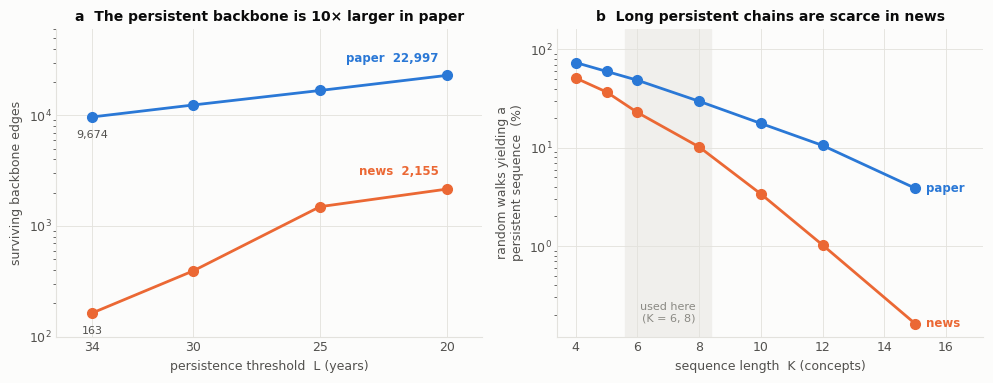

In [26]:
# ============ Fig 1 — persistent structure ============
def edge_count(src,L):
    n=0
    with gzip.open(f"{BASE}/results/tables/{src}_edge_persistence.csv.gz",'rt') as fh:
        for r in csv.DictReader(fh):
            if int(r['longest_run'])>=L: n+=1
    return n
Ls=[20,25,30,34]
edges={s:[edge_count(s,l) for l in Ls] for s in ["news","paper"]}
yK = yield_table

fig,axes=plt.subplots(1,2,figsize=(10.0,3.9))
ax=axes[0]
for s in ["news","paper"]:
    ax.plot(Ls,edges[s],color=CLR[s],lw=2,marker="o",ms=7,clip_on=False,zorder=3)
    ax.annotate(f"{s}  {edges[s][0]:,}",(Ls[0],edges[s][0]),xytext=(-6,10),
                textcoords="offset points",fontsize=8.5,color=CLR[s],fontweight="bold",ha="right")
    ax.annotate(f"{edges[s][-1]:,}",(Ls[-1],edges[s][-1]),xytext=(0,-15),
                textcoords="offset points",fontsize=8,color=INK2,ha="center")
ax.set_yscale("log"); ax.set_xticks(Ls); ax.set_xlim(35.4,18.6)
ax.set_ylim(100,60000)
ax.set_xlabel("persistence threshold  L (years)"); ax.set_ylabel("surviving backbone edges")
ax.set_title("a  The persistent backbone is 10× larger in paper"); tidy(ax)

ax=axes[1]
ax.axvspan(5.6,8.4,color=BAND,zorder=0)
for s in ["news","paper"]:
    d=yK[yK.source==s]
    ax.plot(d.K,d.rate*100,color=CLR[s],lw=2,marker="o",ms=7,clip_on=False,zorder=3)
    ax.annotate(s,(d.K.iloc[-1],d.rate.iloc[-1]*100),xytext=(8,0),textcoords="offset points",
                fontsize=8.5,color=CLR[s],fontweight="bold",va="center")
ax.set_yscale("log"); ax.set_xlim(3.4,17.2); ax.set_ylim(.12,160)
ax.text(7,.17,"used here\n(K = 6, 8)",fontsize=8,color=MUTED,ha="center")
ax.set_xlabel("sequence length  K (concepts)")
ax.set_ylabel("random walks yielding a\npersistent sequence  (%)")
ax.set_title("b  Long persistent chains are scarce in news"); tidy(ax)
plt.tight_layout(); plt.savefig(f"{FIG}/fig1_structure.png",dpi=200); plt.show()

### 8.2 Figure 2

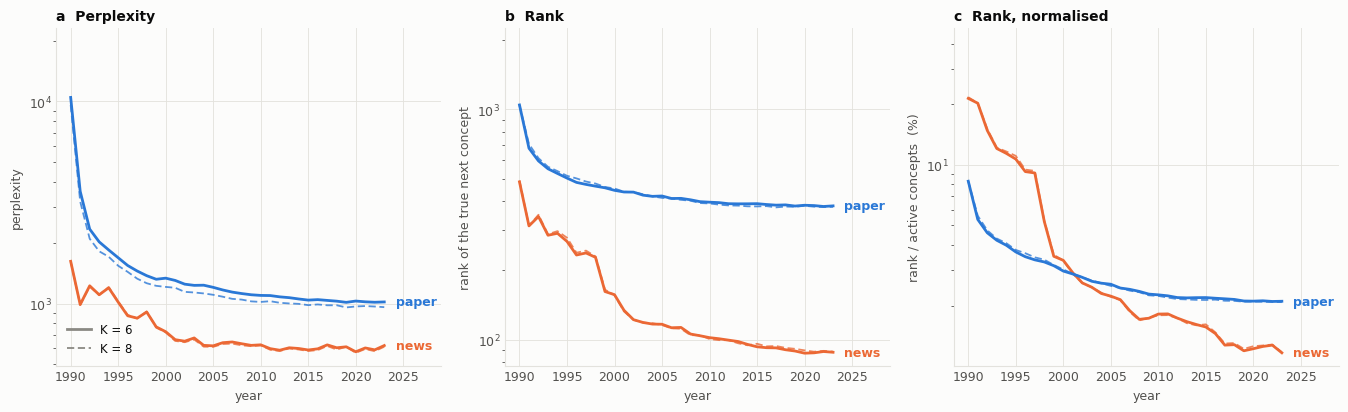

In [27]:
# ============ Fig 2 — trajectories ============
fig,axes=plt.subplots(1,3,figsize=(13.6,4.2),sharex=True)
panels=[("pp_median","perplexity","a  Perplexity"),
        ("rank_median","rank of the true next concept","b  Rank"),
        ("rank_norm_median","rank / active concepts  (%)","c  Rank, normalised")]
for pi,(ax,(col,ylab,title)) in enumerate(zip(axes,panels)):
    for s in ["news","paper"]:
        for K,ls,lw,al in [(6,"-",2.0,1.0),(8,(0,(4,2)),1.3,.8)]:
            d=S(s,K); v=d[col]*(100 if col.endswith("norm_median") else 1)
            ax.plot(d.year,v,color=CLR[s],ls=ls,lw=lw,alpha=al,zorder=3)
        d=S(s,6); last=d[col].iloc[-1]*(100 if col.endswith("norm_median") else 1)
        ax.annotate(s,(2024.2,last),color=CLR[s],fontsize=9,fontweight="bold",va="center")
    ax.set_yscale("log"); ax.set_title(title,loc="left"); tidy(ax)
    ax.set_ylabel(ylab); ax.set_xlabel("year"); ax.set_xlim(1988.5,2029)
    lo,hi=ax.get_ylim(); ax.set_ylim(lo,hi*1.9)
axes[0].legend(handles=[Line2D([],[],color=MUTED,lw=2,ls="-",label="K = 6"),
                        Line2D([],[],color=MUTED,lw=1.3,ls=(0,(4,2)),label="K = 8")],
               loc="lower left",fontsize=8.5)
plt.tight_layout(); plt.savefig(f"{FIG}/fig2_trajectory.png",dpi=200); plt.show()

### 8.4 Figure 4

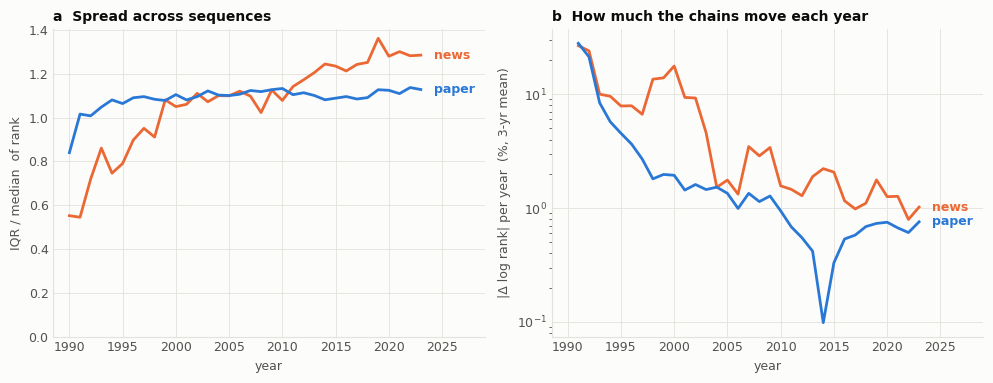

In [28]:
# ============ Fig 4 — dispersion & annual movement (scale-free) ============
fig,axes=plt.subplots(1,2,figsize=(10.0,3.9))
ax=axes[0]
for s in ["news","paper"]:
    d=S(s,6); rel=(d.rank_q75-d.rank_q25)/d.rank_median
    ax.plot(d.year,rel,color=CLR[s],lw=2,zorder=3)
    ax.annotate(s,(2024.2,rel.iloc[-1]),color=CLR[s],fontsize=9,fontweight="bold",va="center")
ax.set_xlim(1988.5,2029); ax.set_ylim(0,None)
ax.set_xlabel("year"); ax.set_ylabel("IQR / median  of rank")
ax.set_title("a  Spread across sequences",loc="left"); tidy(ax)

ax=axes[1]
for s in ["news","paper"]:
    d=S(s,6).set_index("year")
    mv=np.abs(np.diff(np.log(d.rank_median)))
    yy=d.index[1:]; mv=pd.Series(mv,index=yy).rolling(3,center=True,min_periods=1).mean()
    ax.plot(yy,mv*100,color=CLR[s],lw=2,zorder=3)
    ax.annotate(s,(2024.2,mv.iloc[-1]*100),color=CLR[s],fontsize=9,fontweight="bold",va="center")
ax.set_xlim(1988.5,2029); ax.set_yscale("log")
ax.set_xlabel("year"); ax.set_ylabel("|Δ log rank| per year  (%, 3-yr mean)")
ax.set_title("b  How much the chains move each year",loc="left"); tidy(ax)
plt.tight_layout(); plt.savefig(f"{FIG}/fig4_dispersion.png",dpi=200); plt.show()

## 9) 앵커 기반 대응 — 같은 관계를 지나는 두 영역의 실제 경로

두 영역의 궤적을 비교할 때 경로가 서로 다르면, 차이가 **영역 때문인지 경로 때문인지** 구분되지 않는다.
그렇다고 두 영역이 공유하는 구조만으로 경로를 만들면 표본이 없다 — 양쪽 모두에서 지속인 엣지는
12개뿐이고, 그것만으로는 노드 4개짜리 경로가 최대다.

그래서 **앵커**를 쓴다. 양쪽 모두에서 L년 이상 지속인 엣지 하나를 고정하고, 그 엣지를 한가운데 두는
지속 경로를 **각 코퍼스의 자기 지속망에서** 뽑는다.

- 모든 경로가 자기 코퍼스의 실제 지속 경로다 — 합성 그래프도, 없는 엣지도 쓰지 않는다
- 두 영역이 같은 관계를 지나므로 비교의 기준점이 고정된다
- 앵커마다 경로가 여러 개이므로 평균과 산포를 낼 수 있다

앵커별로 먼저 평균을 낸 뒤 **앵커를 표본 단위로** 신뢰구간을 만든다. 같은 앵커를 공유하는 경로들은
독립이 아니므로, 경로 전부를 표본으로 세면 CI가 실제보다 좁아진다.


### 9.0 앵커 선정


In [29]:
# 양쪽 모두에서 L년 이상 지속인 엣지 = 앵커
EG = {s: persistent_graph(s, L) for s in SOURCES}          # (E, adj)
ANCHORS = sorted(set(EG['news'][0]) & set(EG['paper'][0]))

print(f'양쪽 모두 {L}년 이상 지속인 엣지 = 앵커 {len(ANCHORS)}개\n')
for a, b in ANCHORS:
    wn, wp = EG['news'][0][(a, b)], EG['paper'][0][(a, b)]
    print(f"   {vocab.get(a,a):<28} - {vocab.get(b,b):<22}  news {wn}  paper {wp}")


양쪽 모두 20년 이상 지속인 엣지 = 앵커 12개

   architecture                 - software                news (1998, 2023)  paper (1990, 2023)
   automation                   - software                news (1990, 2023)  paper (1990, 2023)
   data collection              - software                news (1997, 2023)  paper (2001, 2023)
   data processing              - software                news (1998, 2023)  paper (1990, 2023)
   interoperability             - software                news (1998, 2023)  paper (1991, 2023)
   medical imaging              - software                news (1998, 2023)  paper (1997, 2019)
   medical imaging              - tomography              news (2000, 2023)  paper (1993, 2023)
   project management           - software                news (1996, 2023)  paper (1995, 2023)
   software                     - systems design          news (1998, 2017)  paper (1998, 2023)
   software                     - usability               news (1998, 2023)  paper (1994, 2023)
   softwar

### 9.1 앵커별 경로 표본

앵커 엣지를 경로 한가운데에 고정하고 양옆으로 `K//2 - 1`개씩 뻗는다
(K=6이면 `· · A B · ·`, K=8이면 `· · · A B · · ·`).
위치를 고정하지 않으면 앵커가 경로의 어디에 오느냐가 결과에 섞인다.

K-1개 엣지의 지속 구간 교집합이 L년 이상인 경로만 채택한다 — 3.1절과 같은 조건이다.


In [30]:
NSEQ_ANCHOR = 500        # 앵커·코퍼스당 경로 수

def sample_anchor_paths(src, anchor, K, n=NSEQ_ANCHOR, L=L, seed=0):
    """앵커 엣지를 한가운데 고정하고 양옆으로 K//2-1개씩 뻗은 지속 경로 n개.

    각 단계에서 창을 L년 이상 유지하는 이웃 중에서만 고른다. 아무 이웃이나 고른 뒤
    조건 위반이면 버리는 방식은 연결선수가 작은 앵커에서 수율이 0에 가까워진다."""
    E, adj = EG[src]
    a, b = anchor
    lo0, hi0 = E[anchor]
    side = K // 2 - 1
    rng = np.random.default_rng(seed)
    out, tries = {}, 0
    while len(out) < n and tries < n * 200:
        tries += 1
        left, right = [a], [b]
        lo, hi, seen, ok = lo0, hi0, {a, b}, True
        for _ in range(side):
            for path in (left, right):
                v, cand = path[-1], []
                for w in adj[v]:
                    w = int(w)
                    if w in seen: continue
                    s, e = E[(min(v, w), max(v, w))]
                    nl, nh = max(lo, s), min(hi, e)
                    if nh - nl + 1 >= L: cand.append((w, nl, nh))
                if not cand: ok = False; break
                w, nl, nh = cand[rng.integers(len(cand))]
                path.append(w); seen.add(w); lo, hi = nl, nh
            if not ok: break
        if ok:
            p = tuple(reversed(left)) + tuple(right)      # (..., a, b, ...)
            out.setdefault(p if p[0] < p[-1] else tuple(reversed(p)), (lo, hi))
    P = (np.array([list(k) for k in out], dtype=np.int64) if out
         else np.empty((0, K), dtype=np.int64))
    W = (np.array([out[k] for k in out], dtype=np.int64) if out
         else np.empty((0, 2), dtype=np.int64))
    return P, W

# 수율 점검 — 한쪽에서라도 경로가 안 나오는 앵커는 쓸 수 없다
yld = {K: [tuple(len(sample_anchor_paths(s, anc, K, seed=100 + ai)[0]) for s in SOURCES)
           for ai, anc in enumerate(ANCHORS)] for K in KS}
USABLE = [ai for ai in range(len(ANCHORS)) if all(min(yld[K][ai]) > 0 for K in KS)]

for K in KS:
    print(f'K={K}')
    for ai, anc in enumerate(ANCHORS):
        n, p = yld[K][ai]
        mark = '' if ai in USABLE else '   <- 제외'
        print(f'  {ai:2d}  {vocab.get(anc[0]):<24} - {vocab.get(anc[1]):<18} {n:5d} {p:6d}{mark}')

print(f'\n쓸 수 있는 앵커 {len(USABLE)}/{len(ANCHORS)}개')
for ai in set(range(len(ANCHORS))) - set(USABLE):
    a, b = ANCHORS[ai]
    for s in SOURCES:
        d = {n: len(EG[s][1][n]) for n in (a, b)}
        print(f'   {vocab.get(a)} - {vocab.get(b)}  [{s}] 연결선수 ' +
              ', '.join(f'{vocab.get(n)} {v}' for n, v in d.items()))


K=6
   0  architecture             - software             500    500
   1  automation               - software             500    500
   2  data collection          - software             500    500
   3  data processing          - software             500    500
   4  interoperability         - software             500    500
   5  medical imaging          - software             500    500
   6  medical imaging          - tomography             0    500   <- 제외
   7  project management       - software             500    500
   8  software                 - systems design       500    500
   9  software                 - usability            500    500
  10  software                 - user interface       500    500
  11  software                 - visualization        500    500
K=8
   0  architecture             - software             500    500
   1  automation               - software             500    500
   2  data collection          - software             500    500
   3  dat

### 9.2 채점

앵커별 경로를 한 배열로 합쳐 `year_scores`에 한 번에 넣는다 — 연도마다 후보집합을 한 번만
만들면 되므로 앵커별로 따로 부르는 것보다 훨씬 빠르다.


In [31]:
arec = []
for src in SOURCES:
    Emb = load_emb(src)
    for K in KS:
        Ps, aid = [], []
        for ai in USABLE:
            P, _ = sample_anchor_paths(src, ANCHORS[ai], K, seed=100 + ai)
            Ps.append(P); aid.append(np.full(len(P), ai))
        P, aid = np.vstack(Ps), np.concatenate(aid)
        np.savez(f'{SEQ}/anchor_seqs_{src}_K{K}.npz', P=P, anchor=aid)
        t0 = time.time()
        for t in range(len(YEARS)):
            pp, rk, nA, allact = year_scores(src, K, t, Emb, P)
            for i in range(len(P)):
                arec.append((src, K, int(aid[i]), YEARS[t], i,
                             pp[i], rk[i], rk[i] / nA, nA, int(allact[i])))
        print(f'{src} K={K}  경로 {len(P):,}개  완료 ({time.time()-t0:.0f}s)')
    del Emb

adf = pd.DataFrame(arec, columns=['source','K','anchor','year','path_id',
                                  'pp','rank','rank_norm','n_active','all_active'])
adf['anchor_name'] = [f'{vocab.get(ANCHORS[a][0])} - {vocab.get(ANCHORS[a][1])}' for a in adf.anchor]
adf.to_csv(f'{SEQ}/anchor_all.csv', index=False)
print(adf.shape)


news K=6  경로 5,500개  완료 (62s)
news K=8  경로 5,500개  완료 (91s)
paper K=6  경로 5,500개  완료 (218s)
paper K=8  경로 5,500개  완료 (310s)
(748000, 11)


### 9.3 앵커별 평균과 앵커 수준 신뢰구간

1. **앵커 안에서** 경로들을 평균한다 -> 앵커·연도별 값
2. **앵커를 표본 단위로** 평균·SD·95% CI를 만든다 (t분포, df = 앵커 수 - 1)

같은 앵커의 경로들은 서로 독립이 아니므로 1단계를 건너뛰면 CI가 실제보다 좁게 나온다.


In [32]:
from scipy import stats as _sst
MET = ['pp', 'rank', 'rank_norm']

# 1단계 - 앵커 안에서 평균
per_anchor = (adf.groupby(['source','K','anchor','anchor_name','year'])[MET]
                 .mean().reset_index())
per_anchor.to_csv(f'{SEQ}/anchor_per_anchor.csv', index=False)

# 2단계 - 앵커를 표본 단위로
def _ci(g):
    o = {}
    for col in MET:
        v = g[col].dropna().values; k = len(v)
        m  = v.mean(); sd = v.std(ddof=1) if k > 1 else np.nan
        h  = _sst.t.ppf(.975, k - 1) * sd / np.sqrt(k) if k > 1 else np.nan
        o[f'{col}_mean'] = m;     o[f'{col}_sd'] = sd
        o[f'{col}_lo']   = m - h; o[f'{col}_hi'] = m + h
    o['n_anchor'] = k
    return pd.Series(o)

asum = per_anchor.groupby(['source','K','year']).apply(_ci).reset_index()
asum.to_csv(f'{SEQ}/anchor_summary.csv', index=False)

print(asum[(asum.K == 6) & asum.year.isin([1995, 2005, 2015, 2023])]
      [['source','year','rank_norm_mean','rank_norm_lo','rank_norm_hi','n_anchor']]
      .to_string(index=False))


source  year  rank_norm_mean  rank_norm_lo  rank_norm_hi  n_anchor
  news  1995        0.107758      0.082675      0.132842      11.0
  news  2005        0.032420      0.025503      0.039336      11.0
  news  2015        0.024413      0.018752      0.030074      11.0
  news  2023        0.017759      0.014937      0.020581      11.0
 paper  1995        0.040136      0.033423      0.046848      11.0
 paper  2005        0.025500      0.019999      0.031000      11.0
 paper  2015        0.021213      0.016608      0.025818      11.0
 paper  2023        0.020883      0.016099      0.025666      11.0


/var/folders/5l/stx39t5d5rlfy95d3t_v47gm0000gn/T/ipykernel_59109/738750414.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  asum = per_anchor.groupby(['source','K','year']).apply(_ci).reset_index()


### 9.4 Figure 5 - 앵커 평균 궤적

선은 앵커 평균의 평균, 띠는 앵커 수준 95% CI.


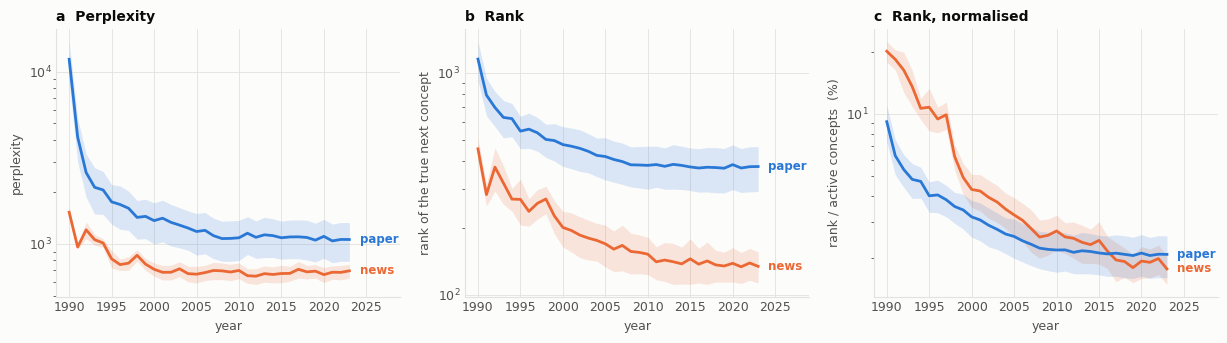

In [36]:
K_A = 6
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.5))
for ax, col, lab in zip(axes, MET,
        ['perplexity', 'rank of the true next concept', 'rank / active concepts  (%)']):
    for src in SOURCES:
        g  = asum[(asum.source == src) & (asum.K == K_A)].sort_values('year')
        y  = g[f'{col}_mean'].values
        lo = g[f'{col}_lo'].values; hi = g[f'{col}_hi'].values
        if col == 'rank_norm': y, lo, hi = y*100, lo*100, hi*100
        ax.fill_between(g.year, lo, hi, color=CLR[src], alpha=.16, lw=0, zorder=2)
        ax.plot(g.year, y, color=CLR[src], lw=2, zorder=3)
        ax.annotate(src, (2024.2, y[-1]), color=CLR[src], fontsize=8.5,
                    fontweight='bold', va='center')
    ax.set_yscale('log'); ax.set_xlim(1988.5, 2029); ax.set_xlabel('year')
    ax.set_ylabel(lab); tidy(ax)
axes[0].set_title('a  Perplexity', loc='left')
axes[1].set_title('b  Rank', loc='left')
axes[2].set_title('c  Rank, normalised', loc='left')
# fig.suptitle(f'앵커 {len(ANCHORS)}개 · 앵커·코퍼스당 경로 {NSEQ_ANCHOR}개 · K={K_A}'
#              '   선 = 앵커 평균, 띠 = 앵커 수준 95% CI', y=1.04, fontsize=9.5, color=INK2)
plt.tight_layout(); plt.savefig(f'{FIG}/fig5_anchor.png', dpi=200, bbox_inches='tight'); plt.show()


### 9.5 Figure 6 - 앵커별

앵커마다 한 칸. 선은 그 앵커의 경로 평균, 띠는 경로 간 사분위 범위.


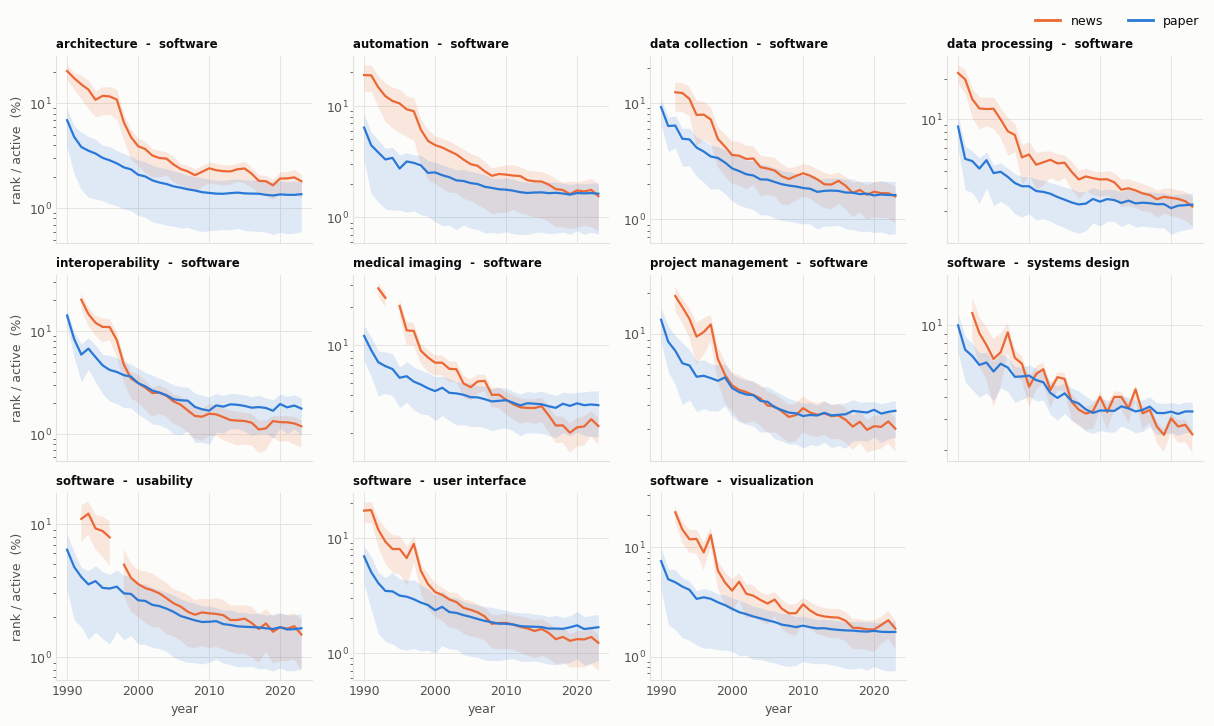

In [34]:
q = (adf[adf.K == K_A].groupby(['source','anchor','year'])['rank_norm']
        .agg(m='mean', q1=lambda v: v.quantile(.25), q3=lambda v: v.quantile(.75))
        .reset_index())

nAn = len(USABLE); ncol = 4; nrow = int(np.ceil(nAn / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.05*ncol, 2.35*nrow), sharex=True)
for k, ax in enumerate(axes.ravel()):
    if k >= nAn: ax.axis('off'); continue
    ai = USABLE[k]
    for src in SOURCES:
        g = q[(q.source == src) & (q.anchor == ai)].sort_values('year')
        ax.fill_between(g.year, g.q1*100, g.q3*100, color=CLR[src], alpha=.14, lw=0, zorder=2)
        ax.plot(g.year, g.m*100, color=CLR[src], lw=1.6, zorder=3)
    a, b = ANCHORS[ai]
    ax.set_title(f'{vocab.get(a,a)}  -  {vocab.get(b,b)}', loc='left', fontsize=8.5)
    ax.set_yscale('log'); ax.set_xlim(1988.5, 2024.5); tidy(ax)
for ax in axes[-1]: ax.set_xlabel('year')
for ax in axes[:, 0]: ax.set_ylabel('rank / active  (%)')
fig.legend(handles=[Line2D([], [], color=CLR[s], lw=2, label=s) for s in SOURCES],
           loc='upper right', bbox_to_anchor=(.995, 1.03), ncol=2)
plt.tight_layout(); plt.savefig(f'{FIG}/fig6_anchor_panels.png', dpi=200, bbox_inches='tight'); plt.show()


### 9.6 후기 기울기 - 앵커별

2009-2023 로그 기울기(%/년)를 앵커마다 낸 뒤 앵커 12개로 평균과 CI를 만든다.


In [35]:
def _slope(g, col, a=2009, b=2023):
    m = (g.year >= a) & (g.year <= b) & (g[col] > 0)
    if m.sum() < 3: return np.nan
    return np.polyfit(g.year[m], np.log(g[col][m]), 1)[0] * 100

rows = []
for (src, K, ai, name), g in per_anchor.groupby(['source','K','anchor','anchor_name']):
    rows.append(dict(source=src, K=K, anchor=ai, anchor_name=name,
                     **{c: _slope(g.sort_values('year'), c) for c in MET}))
sl = pd.DataFrame(rows)
sl.to_csv(f'{SEQ}/anchor_slopes.csv', index=False)

print('2009-2023 로그 기울기 (%/년) - 앵커 평균 ± 95% CI\n')
for K in KS:
    for src in SOURCES:
        g = sl[(sl.source == src) & (sl.K == K)]
        out = []
        for c in MET:
            v = g[c].dropna().values
            h = _sst.t.ppf(.975, len(v)-1) * v.std(ddof=1) / np.sqrt(len(v))
            out.append(f'{c:10s} {v.mean():+6.2f} ± {h:.2f}')
        print(f'  K={K}  {src:6s}  ' + '   '.join(out))

print('\n앵커별 (K=6, 정규화 순위)')
print(sl[sl.K == 6].pivot(index='anchor_name', columns='source', values='rank_norm')
        .round(2).sort_values('news').to_string())


2009-2023 로그 기울기 (%/년) - 앵커 평균 ± 95% CI

  K=6  news    pp          +0.20 ± 0.27   rank        -0.66 ± 0.48   rank_norm   -2.88 ± 0.48
  K=6  paper   pp          -0.33 ± 0.40   rank        -0.22 ± 0.33   rank_norm   -0.49 ± 0.33
  K=8  news    pp          +0.11 ± 0.21   rank        -0.91 ± 0.42   rank_norm   -3.13 ± 0.42
  K=8  paper   pp          -0.38 ± 0.29   rank        -0.24 ± 0.24   rank_norm   -0.51 ± 0.24

앵커별 (K=6, 정규화 순위)
source                         news  paper
anchor_name                               
medical imaging - software    -4.29  -0.47
data processing - software    -3.36  -0.85
automation - software         -3.32  -0.56
data collection - software    -3.21  -1.14
software - visualization      -3.05  -0.90
software - systems design     -3.03  -0.18
software - user interface     -2.91  -0.56
software - usability          -2.52  -0.99
project management - software -2.20   0.51
architecture - software       -2.10  -0.36
interoperability - software   -1.70   0.07


### 9.7 예시 경로 — 앵커마다 news / paper 나란히

앵커마다 2023년 정규화 순위가 가장 낮은(가장 굳은) 경로를 코퍼스별로 뽑는다.
앵커 엣지는 가운데 두 자리이므로 두 코퍼스의 경로가 같은 관계를 지난다.


In [ ]:
N_EX = 2       # 앵커·코퍼스당 예시 수

SEQP = {s: np.load(f'{SEQ}/anchor_seqs_{s}_K{K_A}.npz') for s in SOURCES}
last = adf[(adf.K == K_A) & (adf.year == 2023)]

rows = []
for ai in USABLE:
    a, b = ANCHORS[ai]
    for s in SOURCES:
        P = SEQP[s]['P']
        for _, r in last[(last.source == s) & (last.anchor == ai)].nsmallest(N_EX, 'rank_norm').iterrows():
            rows.append(dict(anchor=f'{vocab.get(a,a)} - {vocab.get(b,b)}', source=s,
                             rank_norm_2023=round(r.rank_norm * 100, 2),
                             path=' -> '.join(vocab.get(int(v), str(v)) for v in P[int(r.path_id)])))

ex = pd.DataFrame(rows)
ex.to_csv(f'{SEQ}/anchor_examples.csv', index=False)

for anc, g in ex.groupby('anchor', sort=False):
    print('=' * 108)
    print(anc)
    for _, r in g.iterrows():
        print(f"  {r.source:6s} {r.rank_norm_2023:5.2f}%   {r.path}")


두 코퍼스의 경로가 같은 관계를 지나는데도 나머지 자리를 채우는 어휘가 갈린다.
뉴스는 경영·정보기술 담론(customer services, acquisitions & mergers, chief executive officers)으로,
논문은 분야가 붙은 일반명사(image (mathematics), class (philosophy), point (geometry))로 채워진다.
